# Limpieza de Datos con `dataprep`: Clientes de un E-commerce

**Curso:** Analitica de Datos / Fundamentos de Ciencia de Datos
**Tema:** Analisis Exploratorio de Datos (EDA) y Limpieza de Datos
**Paqueteria principal:** [`dataprep`](https://docs.dataprep.ai/) (`dataprep.eda`, `dataprep.clean`)


## Contexto de negocio

**NovaShop** es una tienda de e-commerce que quiere lanzar una campana de marketing dirigida
para **aumentar sus ventas**. El equipo de marketing necesita saber **a que segmento de
clientes conviene dirigir la campana** (por ejemplo, por canal de adquisicion, categoria de
producto favorita, rango de edad o nivel de gasto).

Para responder esa pregunta te entregan un extracto de la base de datos de clientes (CRM),
tal como salio del sistema. El problema: **nadie ha limpiado estos datos**. Contienen valores
faltantes, registros duplicados, valores atipicos (outliers) y errores de captura tipicos de
un sistema alimentado por varios canales (web, call center, tienda fisica, importaciones
manuales en Excel).

Tu tarea es **explorar, diagnosticar y limpiar** la base con `dataprep`, y al final **proponer
un segmento de clientes** a priorizar para la campana, con evidencia del analisis.

### Diccionario de datos

| Columna | Descripcion |
|---|---|
| `customer_id` | Identificador del cliente |
| `customer_name` | Nombre completo |
| `email` | Correo electronico |
| `age` | Edad del cliente (anos) |
| `gender` | Genero reportado |
| `country` | Pais del cliente |
| `signup_date` | Fecha de registro en la plataforma |
| `last_purchase_date` | Fecha de la ultima compra |
| `total_purchases` | Numero total de compras realizadas |
| `total_spent` | Gasto total acumulado (moneda local) |
| `avg_order_value` | Valor promedio por orden |
| `favorite_category` | Categoria de producto mas comprada |
| `marketing_channel` | Canal por el que llego el cliente |
| `newsletter_subscribed` | Si esta suscrito al boletin (Yes/No) |
| `satisfaction_score` | Puntaje de satisfaccion (escala 1 a 5) |
| `device_type` | Dispositivo principal de compra |
| `payment_method` | Metodo de pago habitual |

### Dataset

Los datos estan en `data/ecommerce_customers_raw.csv`, en una carpeta relativa a este notebook.

### Instalacion

Si no tienes `dataprep` instalado en tu entorno:

```bash
pip install dataprep
```


In [110]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### Objetivos de aprendizaje

Al terminar este notebook deberias poder:

1. Generar y leer un reporte de EDA automatizado con `dataprep.eda`.
2. Diagnosticar valores nulos, duplicados y outliers, y decidir como tratarlos.
3. Detectar y corregir errores de captura en variables categoricas y numericas.
4. Usar `dataprep.clean` para estandarizar columnas de texto, pais y correo.
5. Traducir un dataset limpio en una recomendacion de negocio basada en evidencia.


### Como trabajar este notebook

- Cada pregunta tiene una celda de codigo vacia (y, cuando aplica, una celda Markdown
  "_Tu respuesta:_") justo debajo. Escribe ahi tu solucion.
- Cuando la pregunta pide interpretar o justificar, responde en la celda Markdown, no
  solo en comentarios de codigo.
- No se espera una unica respuesta "correcta" en las decisiones de limpieza (por ejemplo,
  que hacer con un outlier): lo que importa es que tu criterio este bien justificado.
- Usa `dataprep.eda` para explorar y `dataprep.clean` para estandarizar, salvo que la
  pregunta indique lo contrario.
- Trabaja las secciones en orden: cada una depende del DataFrame limpio de la anterior.


## 1. Carga de datos y primer vistazo

### Pregunta 1

Importa `pandas`, `numpy` y los modulos `create_report`, `plot`, `plot_correlation`, `plot_missing` de `dataprep.eda`, ademas de `clean_country` y `clean_email` de `dataprep.clean`. Carga `data/ecommerce_customers_raw.csv` en un DataFrame llamado `df`. Muestra las primeras 5 filas, la forma (`shape`) y el resultado de `df.info()`.

In [111]:
# Tu codigo aqui
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [112]:
df=pd.read_csv('ecommerce_customers_raw.csv')

In [113]:
df.head(15)

,customer_id,customer_name,email,age,gender,country,signup_date,last_purchase_date,total_purchases,total_spent,avg_order_value,favorite_category,marketing_channel,newsletter_subscribed,satisfaction_score,device_type,payment_method
0,816,Fernanda Rodriguez,fernanda.rodriguez@hotmail.com,29.0,female,mexico,2022-01-23,2023-05-01,7.0,26.91,3.84,SPORTS,Paid Ads,No,1.0,Tablet,Debit Card
1,983,Camila Reyes,camila.reyes@gmail.com,35.0,M,peru,2022-02-04,2023-08-30,7.0,462.75,66.11,Home,Paid Ads,No,1.0,Mobile,Cash on Delivery
2,1486,Pablo Garcia,pablo.garcia@gmail.com,42.0,Male,NaN,2022-01-16,2022-05-24,6.0,NaN,71.98,Home,Organic Search,No,5.0,Tablet,PayPal
3,1286,Ana Torres,ana.torres@yahoo.com,59.0,female,spain,2023-02-23,2024-01-17,5.0,58.73,11.75,Beauty,referral,Yes,3.0,Desktop,Debit Card
4,1222,Andres Gonzalez,andres.gonzalez@outlook.com,30.0,Male,Espana,2022-03-10,2022-08-13,3.0,30.99,10.33,Home,PAID ADS,Yes,4.0,Mobile,Debit Card
5,264,Gabriela Flores,gabriela.flores@outlook.com,22.0,Other,Peru,2024-06-05,2024-08-06,4.0,70.5,17.62,Home,Email,Yes,4.0,Desktop,PayPal
6,587,Javier Sanchez,javier.sanchez@gmail.com,46.0,male,us,2022-10-01,2022-10-21,8.0,182.15,22.77,electronics,REFERRAL,No,NaN,Desktop,Credit Card
7,204,Javier Perez,javier.perez@gmail.com,53.0,FEMALE,United States,2024-04-02,2024-11-26,4.0,249.47,62.37,HOME,referral,No,2.0,Desktop,Debit Card
8,1997,Andres Garcia,andres.garcia@outlook.com,51.0,Male,Brazil,2022-10-14,2023-03-23,6.0,146.39,24.40,Electronics,Paid Ads,Yes,2.0,Mobile,Credit Card
9,1555,Diego Ramirez,diego.ramirez@yahoo.com,25.0,MALE,Mexico,2022-06-23,2023-05-11,2.0,38.97,19.48,Books,Social Media,Yes,2.0,Mobile,Cash on Delivery


_Tu respuesta:_

## 2. Analisis Exploratorio de Datos (EDA) con `dataprep.eda`

### Pregunta 2

Genera un reporte EDA completo con `create_report(df, title=...)` y guardalo como HTML con `.save("reporte_inicial")`. Muestralo tambien embebido en el notebook. Responde: ¿cuantas variables identifica dataprep como numericas y cuantas como categoricas/texto? ¿por que `total_spent` no queda clasificada como numerica?

In [114]:
# Tu codigo aqui
df.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
customer_id,2040.0,1001.7,576.8,1.0,500.8,1001.5,1499.2,2000.0
age,1918.0,38.0,12.8,-5.0,30.0,38.0,46.0,200.0
total_purchases,2040.0,6.0,2.5,-3.0,4.0,6.0,8.0,15.0
avg_order_value,2040.0,48.7,69.6,1.0,14.0,28.1,55.7,981.2
satisfaction_score,1879.0,3.0,1.4,-1.0,2.0,3.0,4.0,10.0


_Tu respuesta:_

### Pregunta 3

Usa `plot(df, "columna")` para visualizar la distribucion de `age`, `total_purchases`, `avg_order_value` y `satisfaction_score`. ¿Que variable(s) muestran valores que no tienen sentido de negocio (por ejemplo edades imposibles, compras negativas o puntajes fuera de escala)?

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'total_purchases'}>],
       [<Axes: title={'center': 'avg_order_value'}>,
        <Axes: title={'center': 'satisfaction_score'}>]], dtype=object)

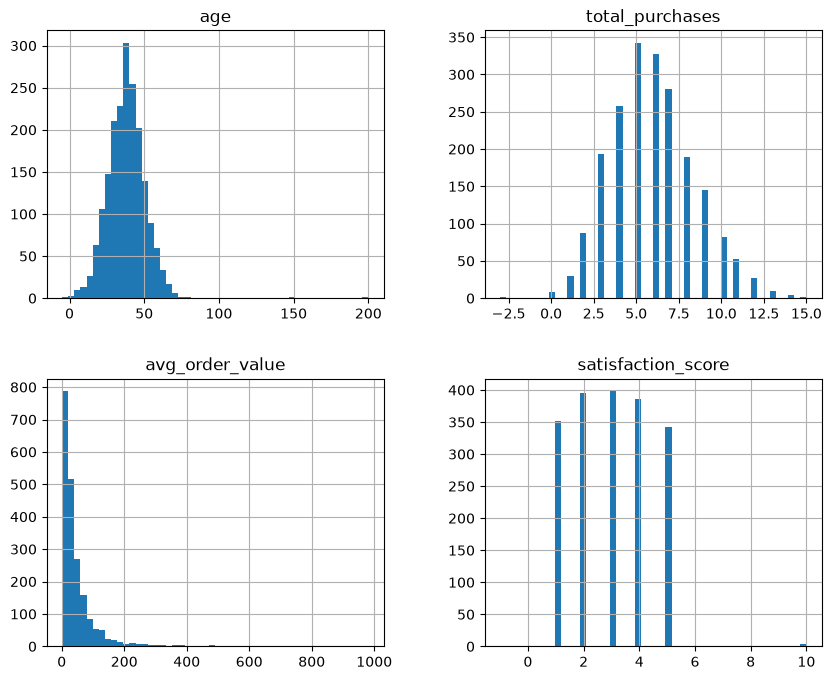

In [115]:
# Tu codigo aqui
#Histograma de las variables agem total_purcheses, avg_order_value, satisfaction_score
df[["age","total_purchases","avg_order_value","satisfaction_score"]].hist(figsize=(10,8),bins=50)


_Tu respuesta:_

### Pregunta 4

Usa `plot_correlation(df)` para explorar la correlacion entre las variables numericas. Por construccion del negocio, ¿que relacion esperarias que fuera fuerte (por ejemplo entre `total_purchases` y `avg_order_value`), y se observa asi en el reporte?

In [116]:
# Tu codigo aqui
df[["age","total_purchases","avg_order_value","satisfaction_score"]].corr().round(2)

,age,total_purchases,avg_order_value,satisfaction_score
age,1.00,-0.01,-0.02,-0.02
total_purchases,-0.01,1.00,-0.35,-0.01
avg_order_value,-0.02,-0.35,1.00,-0.02
satisfaction_score,-0.02,-0.01,-0.02,1.00


_Tu respuesta:_

## 3. Valores nulos

### Pregunta 5

Usa `plot_missing(df)` para visualizar el patron de valores faltantes. Complementa con `df.isna().mean().sort_values(ascending=False) * 100` para obtener el porcentaje exacto de nulos por columna. ¿El patron de nulos parece aleatorio (MCAR) o sistematico (por ejemplo, concentrado en las mismas filas o correlacionado con otra variable)?

In [117]:
# Tu codigo aqui
df.isnull().sum()


customer_id                0
customer_name              0
email                     81
age                      122
gender                     0
country                   60
signup_date                0
last_purchase_date        41
total_purchases            0
total_spent               60
avg_order_value            0
favorite_category          0
marketing_channel          0
newsletter_subscribed      0
satisfaction_score       161
device_type                0
payment_method             0
dtype: int64

In [118]:
#porcentaje de valores nulos
(df.isnull().sum()/len(df))*100

customer_id              0.000000
customer_name            0.000000
email                    3.970588
age                      5.980392
gender                   0.000000
country                  2.941176
signup_date              0.000000
last_purchase_date       2.009804
total_purchases          0.000000
total_spent              2.941176
avg_order_value          0.000000
favorite_category        0.000000
marketing_channel        0.000000
newsletter_subscribed    0.000000
satisfaction_score       7.892157
device_type              0.000000
payment_method           0.000000
dtype: float64

In [119]:
#total missing values
df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100

np.float64(1.513840830449827)

_Tu respuesta:_

### Pregunta 6

Decide y aplica una estrategia de tratamiento para cada columna con nulos, justificando la eleccion (eliminar la fila, imputar con la mediana/moda, o dejarla pendiente para la seccion de errores de captura). Guarda el resultado en un nuevo DataFrame `df_clean`. Nota: no fuerces `total_spent` a numerico todavia -- todavia contiene valores de texto que se resuelven en la Seccion 5; aqui solo corrige sus valores realmente nulos.

In [120]:
# Tu codigo aqui
age_median=df["age"].median()
print(age_median)
df["age"]=df["age"].fillna(age_median)


38.0


In [121]:
#verificar que no hay missing values
df.isnull().sum()

customer_id                0
customer_name              0
email                     81
age                        0
gender                     0
country                   60
signup_date                0
last_purchase_date        41
total_purchases            0
total_spent               60
avg_order_value            0
favorite_category          0
marketing_channel          0
newsletter_subscribed      0
satisfaction_score       161
device_type                0
payment_method             0
dtype: int64

In [122]:
#imputamos valores faltantes de la variable satifaction score con la mediana 
satisfaction_score_median=df["satisfaction_score"].median()
df["satisfaction_score"]=df["satisfaction_score"].fillna(satisfaction_score_median)

#verificamos que no queden valores faltantes en satisfaction score
df["satisfaction_score"].isnull().sum()

np.int64(0)

_Tu respuesta:_

## 4. Registros duplicados

### Pregunta 7

Identifica registros duplicados exactos con `df_clean.duplicated()` y clientes con `customer_id` repetido con `df_clean["customer_id"].duplicated()`. ¿Cuantos hay de cada tipo? ¿A que crees que se debe cada tipo de duplicado?

In [ ]:
# calculamos los duplicados
df.duplicated().sum()
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

np.int64(29)

In [124]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,customer_id,customer_name,email,age,gender,country,signup_date,last_purchase_date,total_purchases,total_spent,avg_order_value,favorite_category,marketing_channel,newsletter_subscribed,satisfaction_score,device_type,payment_method
133,232,Pablo Rodriguez,pablo.rodriguez@outlook.com,30.0,Female,Mexico,2022-09-30,2023-01-10,6.0,991.49,165.25,Electronics,ORGANIC SEARCH,No,3.0,Desktop,Credit Card
636,232,Pablo Rodriguez,pablo.rodriguez@outlook.com,30.0,Female,Mexico,2022-09-30,2023-01-10,6.0,991.49,165.25,Electronics,ORGANIC SEARCH,No,3.0,Desktop,Credit Card
176,285,Valentina Diaz,valentina.diaz@gmail.com,52.0,male,argentina,2022-12-22,2023-09-24,9.0,470.19,52.24,Electronics,Paid Ads,Yes,4.0,Tablet,Debit Card
580,285,Valentina Diaz,valentina.diaz@gmail.com,52.0,male,argentina,2022-12-22,2023-09-24,9.0,470.19,52.24,Electronics,Paid Ads,Yes,4.0,Tablet,Debit Card
1142,386,Maria Jimenez,maria.jimenez@yahoo.com,52.0,FEMALE,mexico,2023-02-28,2023-04-02,5.0,123.09,24.62,Home,social media,No,4.0,Desktop,Credit Card
1711,386,Maria Jimenez,maria.jimenez@yahoo.com,52.0,FEMALE,mexico,2023-02-28,2023-04-02,5.0,123.09,24.62,Home,social media,No,4.0,Desktop,Credit Card
774,443,Maria Garcia,maria.garcia@yahoo.com,31.0,male,Brasil,2022-01-17,2022-08-19,8.0,169.99,21.25,beauty,Organic Search,Yes,4.0,Desktop,Credit Card
902,443,Maria Garcia,maria.garcia@yahoo.com,31.0,male,Brasil,2022-01-17,2022-08-19,8.0,169.99,21.25,beauty,Organic Search,Yes,4.0,Desktop,Credit Card
973,448,Jorge Gomez,jorge.gomez@gmail.com,41.0,F,U.S.A,2022-02-11,2023-01-05,8.0,24.61,3.08,sports,Organic Search,Yes,4.0,Mobile,PayPal
1710,448,Jorge Gomez,jorge.gomez@gmail.com,41.0,F,U.S.A,2022-02-11,2023-01-05,8.0,24.61,3.08,sports,Organic Search,Yes,4.0,Mobile,PayPal


In [125]:
# eliminamos las observaciones duplicadas
df=df.drop_duplicates()

#verificamos
df.duplicated().sum()

np.int64(0)

_Tu respuesta:_

### Pregunta 8

Elimina los duplicados de forma apropiada: para los duplicados exactos conserva solo una copia; para los `customer_id` repetidos con informacion distinta, conserva el registro mas reciente segun `last_purchase_date`.

In [126]:
# Value counts de las variables gender, country, favorite_category y marketing_channel
print(df["gender"].value_counts())
print(df["country"].value_counts())
print(df["favorite_category"].value_counts())
print(df["marketing_channel"].value_counts())

gender
M           195
F           193
MALE        192
FEMALE      191
male        190
Femenino    190
 Male       189
female      187
Female      177
Male        171
Other        55
other        43
OTHER        38
Name: count, dtype: int64
country
Mexico            273
 Mexico           154
mexico            136
MEXICO            131
Colombia           94
us                 89
COLOMBIA           85
Argentina          80
colombia           80
USA                79
United States      78
United States      71
argentina          69
U.S.A              68
Espana             65
chile              65
spain              63
Spain              59
Chile              56
Peru               54
Brazil             30
peru               26
Brasil             23
brazil             23
Name: count, dtype: int64
favorite_category
Home             228
Beauty           224
Books            223
Electronics      206
Clothing         192
Sports           189
CLOTHING          63
beauty            61
sports     

_Tu respuesta:_

## 5. Errores de captura (texto, categorias y formato)

### Pregunta 9

Explora los valores unicos de `gender`, `country`, `favorite_category` y `marketing_channel` con `.value_counts()`. Revisa tambien `df_clean["total_spent"].apply(type).value_counts()`. Lista al menos tres tipos de inconsistencias de captura que encuentres.

In [127]:
# valores unicos de la variable gender
df["gender"].unique()

<StringArray>
[  'female',        'M',    ' Male',     'Male',    'Other',     'male',
   'FEMALE',     'MALE',        'F', 'Femenino',    'other',   'Female',
    'OTHER']
Length: 13, dtype: str

In [128]:
df["gender"] = df["gender"].replace({ "Male": "M", "male": "M", "MALE": "M"," Male": "M"
                                     , "Female" : "F", "female": "F", "FEMALE": "F","Femenino": "F", "other":"O", "Other":"O","Other":"O"})
    
    

In [129]:
df["gender"].value_counts()

gender
F        938
M        937
O         98
OTHER     38
Name: count, dtype: int64

_Tu respuesta:_

### Pregunta 10

Usa `clean_country()` de `dataprep.clean` sobre la columna `country` (con `output_format="name"`) para estandarizar los nombres de pais, y `clean_email()` sobre `email` para validar su formato. ¿Cuantos valores quedan sin reconocer (nulos) en cada columna resultante?

In [130]:
# enlistamos los valores unicos de la columna country
df["country"].unique()


<StringArray>
[        'mexico',           'peru',              nan,          'spain',
         'Espana',           'Peru',             'us',  'United States',
         'Brazil',         'Mexico',          'Spain',      'Argentina',
       'Colombia',        ' Mexico',          'U.S.A', 'United States ',
         'Brasil',         'MEXICO',       'colombia',       'COLOMBIA',
          'Chile',      'argentina',            'USA',          'chile',
         'brazil']
Length: 25, dtype: str

In [131]:
df["country"] = df["country"].replace({
    "mexico": "MX", "Mexico": "MX", "MEXICO": "MX", " Mexico": "MX",
    "peru": "PE", "Peru": "PE",
    "spain": "ES", "Spain": "ES", "Espana": "ES",
    "us": "US", "USA": "US", "U.S.A": "US", "United States": "US","United States ":"US",
    "Brazil": "BR", "Brasil": "BR", "brazil": "BR",
    "argentina": "AR", "Argentina": "AR",
    "colombia": "CO", "Colombia": "CO", "COLOMBIA": "CO",
    "chile": "CH", "Chile": "CH"
})

df["country"].value_counts(dropna=False)

country
MX     694
US     385
CO     259
ES     187
AR     149
CH     121
PE      80
BR      76
NaN     60
Name: count, dtype: int64

_Tu respuesta:_

### Pregunta 11

Estandariza `gender`, `favorite_category` y `marketing_channel` (quita espacios, unifica mayusculas/minusculas, mapea abreviaciones a la categoria completa). Reemplaza `country` por la version limpia y decide que hacer con los nulos que queden. Convierte `total_spent` a numerico (quitando el simbolo `$` y las comas). Por ultimo, revisa que `last_purchase_date` no sea anterior a `signup_date` y corrige los casos inconsistentes.

In [132]:
# imputamos la moda en los valores faltantes de country 
moda_country=df["country"].mode()
moda_country

0    MX
Name: country, dtype: str

In [133]:
# imputamos la moda en los valores faltantes de country 
df["country"].fillna(moda_country[0],inplace=True)

df["country"].isnull().sum()


/tmp/ipykernel_4905/3309527427.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["country"].fillna(moda_country[0],inplace=True)


np.int64(60)

In [134]:
df.info()


<class 'pandas.DataFrame'>
Index: 2011 entries, 0 to 2039
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            2011 non-null   int64  
 1   customer_name          2011 non-null   str    
 2   email                  1931 non-null   str    
 3   age                    2011 non-null   float64
 4   gender                 2011 non-null   str    
 5   country                1951 non-null   str    
 6   signup_date            2011 non-null   str    
 7   last_purchase_date     1971 non-null   str    
 8   total_purchases        2011 non-null   float64
 9   total_spent            1951 non-null   str    
 10  avg_order_value        2011 non-null   float64
 11  favorite_category      2011 non-null   str    
 12  marketing_channel      2011 non-null   str    
 13  newsletter_subscribed  2011 non-null   str    
 14  satisfaction_score     2011 non-null   float64
 15  device_type         

_Tu respuesta:_

In [135]:
#Convierte `total_spent` a numerico (quitando el simbolo `$` y las comas).
df["total_spent"] = (
    df["total_spent"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)


In [136]:
df.head()

,customer_id,customer_name,email,age,gender,country,signup_date,last_purchase_date,total_purchases,total_spent,avg_order_value,favorite_category,marketing_channel,newsletter_subscribed,satisfaction_score,device_type,payment_method
0,816,Fernanda Rodriguez,fernanda.rodriguez@hotmail.com,29.0,F,MX,2022-01-23,2023-05-01,7.0,26.91,3.84,SPORTS,Paid Ads,No,1.0,Tablet,Debit Card
1,983,Camila Reyes,camila.reyes@gmail.com,35.0,M,PE,2022-02-04,2023-08-30,7.0,462.75,66.11,Home,Paid Ads,No,1.0,Mobile,Cash on Delivery
2,1486,Pablo Garcia,pablo.garcia@gmail.com,42.0,M,NaN,2022-01-16,2022-05-24,6.0,NaN,71.98,Home,Organic Search,No,5.0,Tablet,PayPal
3,1286,Ana Torres,ana.torres@yahoo.com,59.0,F,ES,2023-02-23,2024-01-17,5.0,58.73,11.75,Beauty,referral,Yes,3.0,Desktop,Debit Card
4,1222,Andres Gonzalez,andres.gonzalez@outlook.com,30.0,M,ES,2022-03-10,2022-08-13,3.0,30.99,10.33,Home,PAID ADS,Yes,4.0,Mobile,Debit Card


## 6. Outliers

### Pregunta 12

Ahora que `total_spent` es numerica, usa `plot(df_clean, "columna")` para revisar de nuevo `age`, `total_spent`, `total_purchases` y `avg_order_value`. ¿Que observaciones parecen errores de captura y cuales podrian ser clientes "premium" legitimos?

<Axes: xlabel='total_spent', ylabel='Count'>

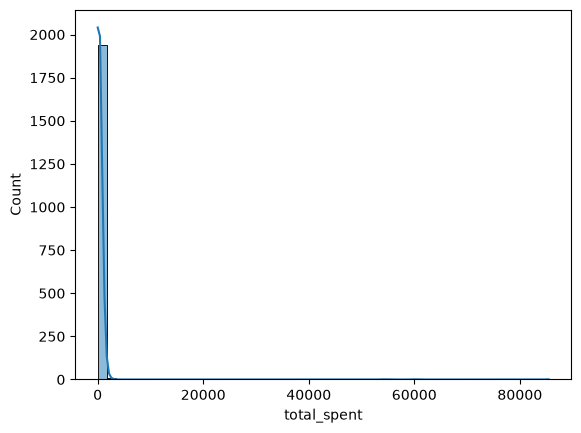

In [137]:
sns.histplot(df["total_spent"], bins=50, kde=True)

<Axes: xlabel='total_spent'>

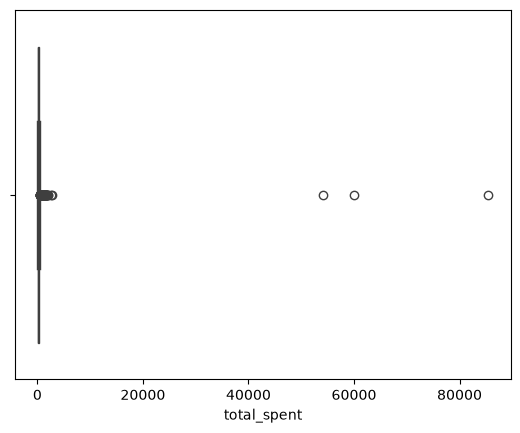

In [138]:
# Tu codigo aqui
sns.boxplot(x=df["total_spent"])

_Tu respuesta:_

### Pregunta 13

Calcula los limites de outliers con la regla del rango intercuartilico (IQR: por debajo de Q1 - 1.5*IQR o por encima de Q3 + 1.5*IQR) para `age`, `total_spent`, `total_purchases` y `avg_order_value`. ¿Cuantas observaciones caen fuera de esos limites en cada variable?

In [139]:
# Calcula los limites de outliers con la regla del rango intercuartilico (IQR: por debajo de Q1 - 1.5*IQR o por encima de Q3 + 1.5*IQR) para `age`, `total_spent`, `total_purchases` y `avg_order_value`. ¿Cuantas observaciones caen fuera de esos limites en cada variable?
Q1 = df['total_spent'].quantile(0.25)
Q3 = df['total_spent'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


In [145]:
#aplicar la ley de iqr total_spent
#aplicamos la regla del iqr para eliminar los outliers de la variable `total_spent`
df = df[(df['total_spent'] >= limite_inferior) & (df['total_spent'] <= limite_superior)]


<Axes: xlabel='total_spent'>

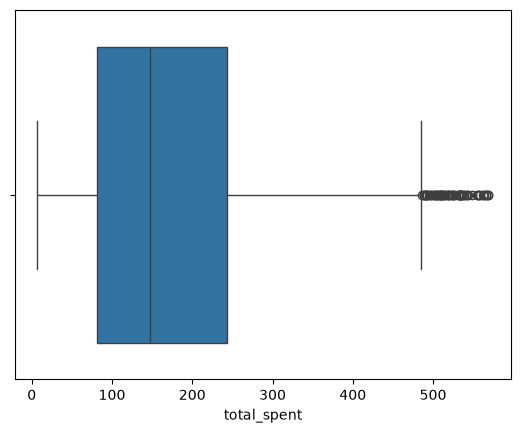

In [146]:
sns.boxplot(x=df["total_spent"])

_Tu respuesta:_

### Pregunta 14

Trata los outliers columna por columna, justificando cada decision: (a) elimina valores de `age` que sean imposibles (negativos o mayores a 100); (b) elimina `total_purchases` negativos o extremadamente altos (por ejemplo, mayores a 100); (c) decide si conservar, winsorizar (recortar al percentil 99) o eliminar los valores extremos de `total_spent`; (d) corrige `satisfaction_score` fuera de la escala 1-5.

In [149]:
# Tu codigo aqui
# (a) elimina valores de "age" que sean imposibles (negativos o mayores a 100)
df = df[(df["age"] >= 0) & (df["age"] <= 100)]

In [151]:
#histograma
df["age"].describe().round(1)

count    1807.0
mean       37.8
std        11.5
min         0.0
25%        30.0
50%        38.0
75%        45.0
max        79.0
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

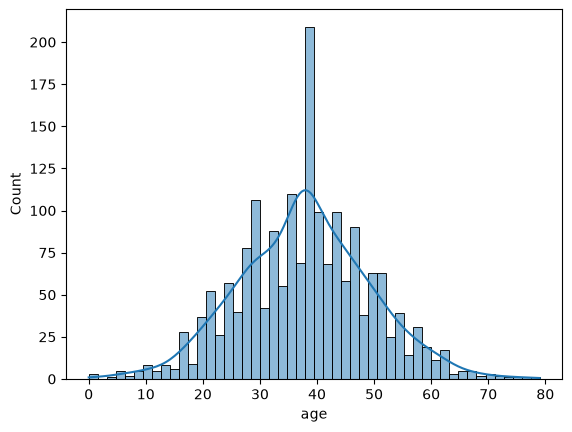

In [152]:
#histograma de la variable age 
sns.histplot(df["age"], bins=50, kde=True)

_Tu respuesta:_

## 7. Validacion final y sintesis de negocio

### Pregunta 15

Vuelve a correr `create_report(df_clean, ...)` y guardalo como `"reporte_final"`. Compara con el reporte inicial de la Pregunta 2: ¿que cambio en nulos, duplicados, tipos de dato y forma del dataset?

In [142]:
# Tu codigo aqui


_Tu respuesta:_

### Pregunta 16

Con `df_clean`, identifica el segmento de clientes que NovaShop deberia priorizar para aumentar ventas. Agrupa por `marketing_channel` y por `favorite_category`, comparando `total_spent` promedio, `avg_order_value` promedio y `satisfaction_score` promedio. Redacta una recomendacion de 3 a 5 lineas para el equipo de marketing, con evidencia numerica de tu analisis.

In [143]:
# Tu codigo aqui


_Tu respuesta:_

### Pregunta 17

Reflexion breve: ¿que decisiones de limpieza que tomaste en este notebook podrian introducir sesgo en la recomendacion de negocio de la pregunta anterior? ¿que verificarias con el equipo que genera los datos antes de confiar del todo en esta conclusion?

In [144]:
# Tu codigo aqui


_Tu respuesta:_